## **Exploratory Data Analysis (EDA) :**

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

from src.dataset_eda import FODEDA

In [2]:
DATASET_ROOT = (
    PROJECT_ROOT /
    "FODPascalVOCFormat-V.2.1"/"FODPascalVOCFormat-V.2.1" /
    "VOC2007"
)

BUILT_ROOT = (
    PROJECT_ROOT /
    "dataset" /
    "built"
)

eda = FODEDA(
    dataset_root=DATASET_ROOT,
    built_root=BUILT_ROOT
)

In [3]:
annotations_df = eda.load_annotations()

In [4]:
annotations_df.head()

,image_id,class,image_width,image_height,xmin,ymin,xmax,ymax,bbox_width,bbox_height,bbox_area,relative_area,aspect_ratio
0,000000,Battery,300.0,300.0,138.2219,104.2833,151.4406,148.3472,13.2187,44.0639,582.467475,0.006472,0.299989
1,000001,Battery,300.0,300.0,138.2422,104.7611,151.4625,148.8250,13.2203,44.0639,582.537977,0.006473,0.300026
2,000002,Battery,300.0,300.0,138.2641,105.2389,151.4828,149.3028,13.2187,44.0639,582.467475,0.006472,0.299989
3,000003,Battery,300.0,300.0,138.2844,105.7167,151.5032,149.7806,13.2188,44.0639,582.471881,0.006472,0.299992
4,000004,Battery,300.0,300.0,138.3047,106.1945,151.5234,150.2555,13.2187,44.0610,582.429141,0.006471,0.300009


In [5]:
annotations_df.shape

(34472, 13)

In [6]:
summary = eda.summary(
    annotations_df
)

summary

{'total_objects': 34472,
 'unique_images': 33793,
 'unique_classes': 31,
 'mean_objects_per_image': 1.0200929186517917,
 'median_bbox_area': 3250.879330005,
 'median_relative_bbox_area': 0.0361208814445,
 'median_aspect_ratio': 0.7117432653688671}

In [7]:
class_df = eda.class_distribution(
    annotations_df
)

class_df

,class,object_count
0,Bolt,3300
1,Pliers,2884
2,Wrench,2568
3,Washer,2139
4,Wire,2138
5,PlasticPart,2008
6,LuggageTag,1686
7,Cutter,1352
8,Label,1310
9,Nut,1303


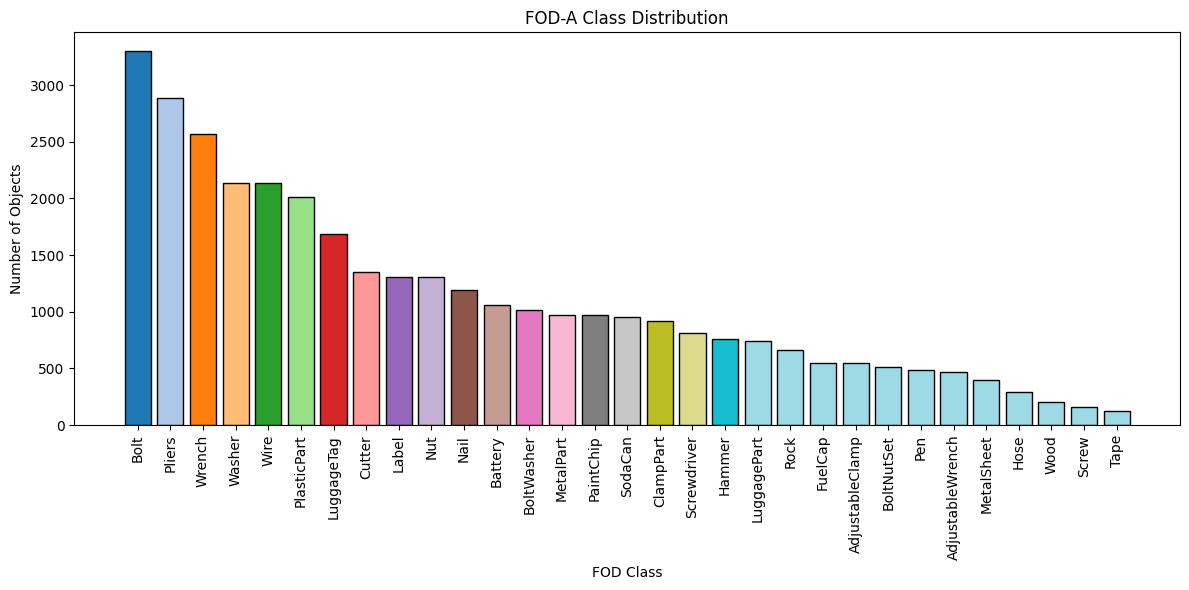

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Count the number of unique classes to dynamically generate colors
num_classes = len(class_df["class"])
colors = plt.cm.tab20(range(num_classes))  # Generates a distinct color for each bar

plt.bar(
    class_df["class"],
    class_df["object_count"],
    color=colors,         # Applies the colorful palette
    edgecolor="black"     # Optional: adds a clean border to each bar
)

plt.xticks(rotation=90)

plt.xlabel("FOD Class")
plt.ylabel("Number of Objects")

plt.title("FOD-A Class Distribution")

plt.tight_layout()
plt.show()


In [9]:
# # * Objects per image

objects_df = eda.objects_per_image(
    annotations_df
)

objects_df.head()

,image_id,object_count
0,000000,1
1,000001,1
2,000002,1
3,000003,1
4,000004,1


In [10]:
objects_df["object_count"].describe()

count    33793.000000
mean         1.020093
std          0.140320
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: object_count, dtype: float64

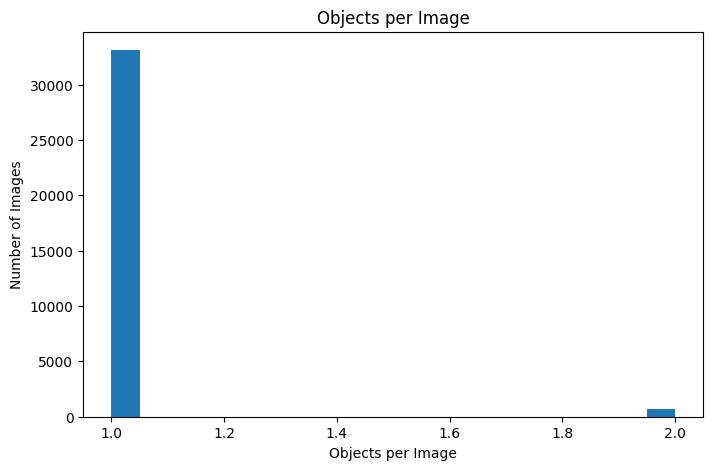

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(
    objects_df["object_count"],
    bins=20
)

plt.xlabel("Objects per Image")
plt.ylabel("Number of Images")

plt.title(
    "Objects per Image"
)

plt.show()

In [12]:
# # *Bounding-box size

annotations_df[
    [
        "bbox_width",
        "bbox_height",
        "bbox_area",
        "relative_area"
    ]
].describe()

,bbox_width,bbox_height,bbox_area,relative_area
count,34472.000000,34472.000000,34472.000000,34472.000000
mean,62.816476,82.323644,7079.324836,0.078659
std,52.290935,63.056940,9736.634473,0.108185
min,3.372600,3.339400,21.411288,0.000238
25%,23.196025,32.356625,842.081992,0.009356
50%,48.447500,64.822250,3250.879330,0.036121
75%,87.233375,119.562100,9261.234083,0.102903
max,300.000000,300.000000,77785.684424,0.864285


In [13]:
# # * Tiny-object analysis

tiny_1 = (
    annotations_df["relative_area"] <= 0.01
).mean() * 100

tiny_5 = (
    annotations_df["relative_area"] <= 0.05
).mean() * 100

print(
    f"Objects <= 1% of image: {tiny_1:.2f}%"
)

print(
    f"Objects <= 5% of image: {tiny_5:.2f}%"
)

Objects <= 1% of image: 26.27%
Objects <= 5% of image: 57.52%


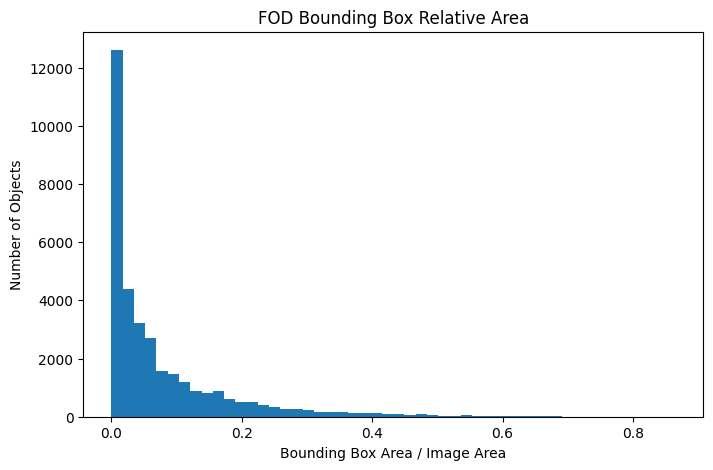

In [14]:
# # * Bounding-box area distribution

plt.figure(figsize=(8, 5))

plt.hist(
    annotations_df["relative_area"],
    bins=50
)

plt.xlabel(
    "Bounding Box Area / Image Area"
)

plt.ylabel("Number of Objects")

plt.title(
    "FOD Bounding Box Relative Area"
)

plt.show()

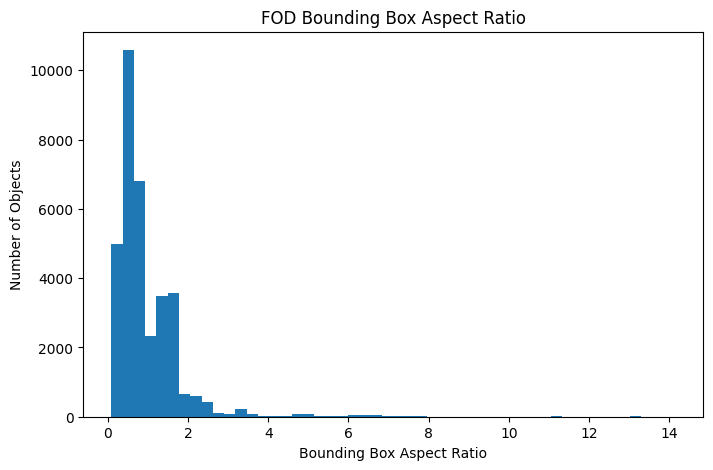

In [15]:
# # * Aspect ratio

plt.figure(figsize=(8, 5))

plt.hist(
    annotations_df["aspect_ratio"].dropna(),
    bins=50
)

plt.xlabel(
    "Bounding Box Aspect Ratio"
)

plt.ylabel("Number of Objects")

plt.title(
    "FOD Bounding Box Aspect Ratio"
)

plt.show()

In [16]:
# # * Resolution

resolution_df = eda.resolution_distribution(
    annotations_df
)

resolution_df

,image_width,image_height,image_count
0,300.0,300.0,1


In [17]:
# # * Weather

weather_df = eda.weather_distribution()

weather_df

,Weather,count
0,0,26577
1,1,7216


In [18]:
weather_map = {
    0: "Dry",
    1: "Wet"
}

weather_df["Weather"] = (
    weather_df["Weather"]
    .map(weather_map)
)

weather_df

,Weather,count
0,Dry,26577
1,Wet,7216


In [19]:
# # * Lighting

light_df = eda.lighting_distribution()

light_df

,Light,count
0,0,16942
1,1,12464
2,2,4387


In [20]:
light_map = {
    0: "Bright",
    1: "Dim",
    2: "Dark"
}

light_df["Light"] = (
    light_df["Light"]
    .map(light_map)
)

light_df

,Light,count
0,Bright,16942
1,Dim,12464
2,Dark,4387


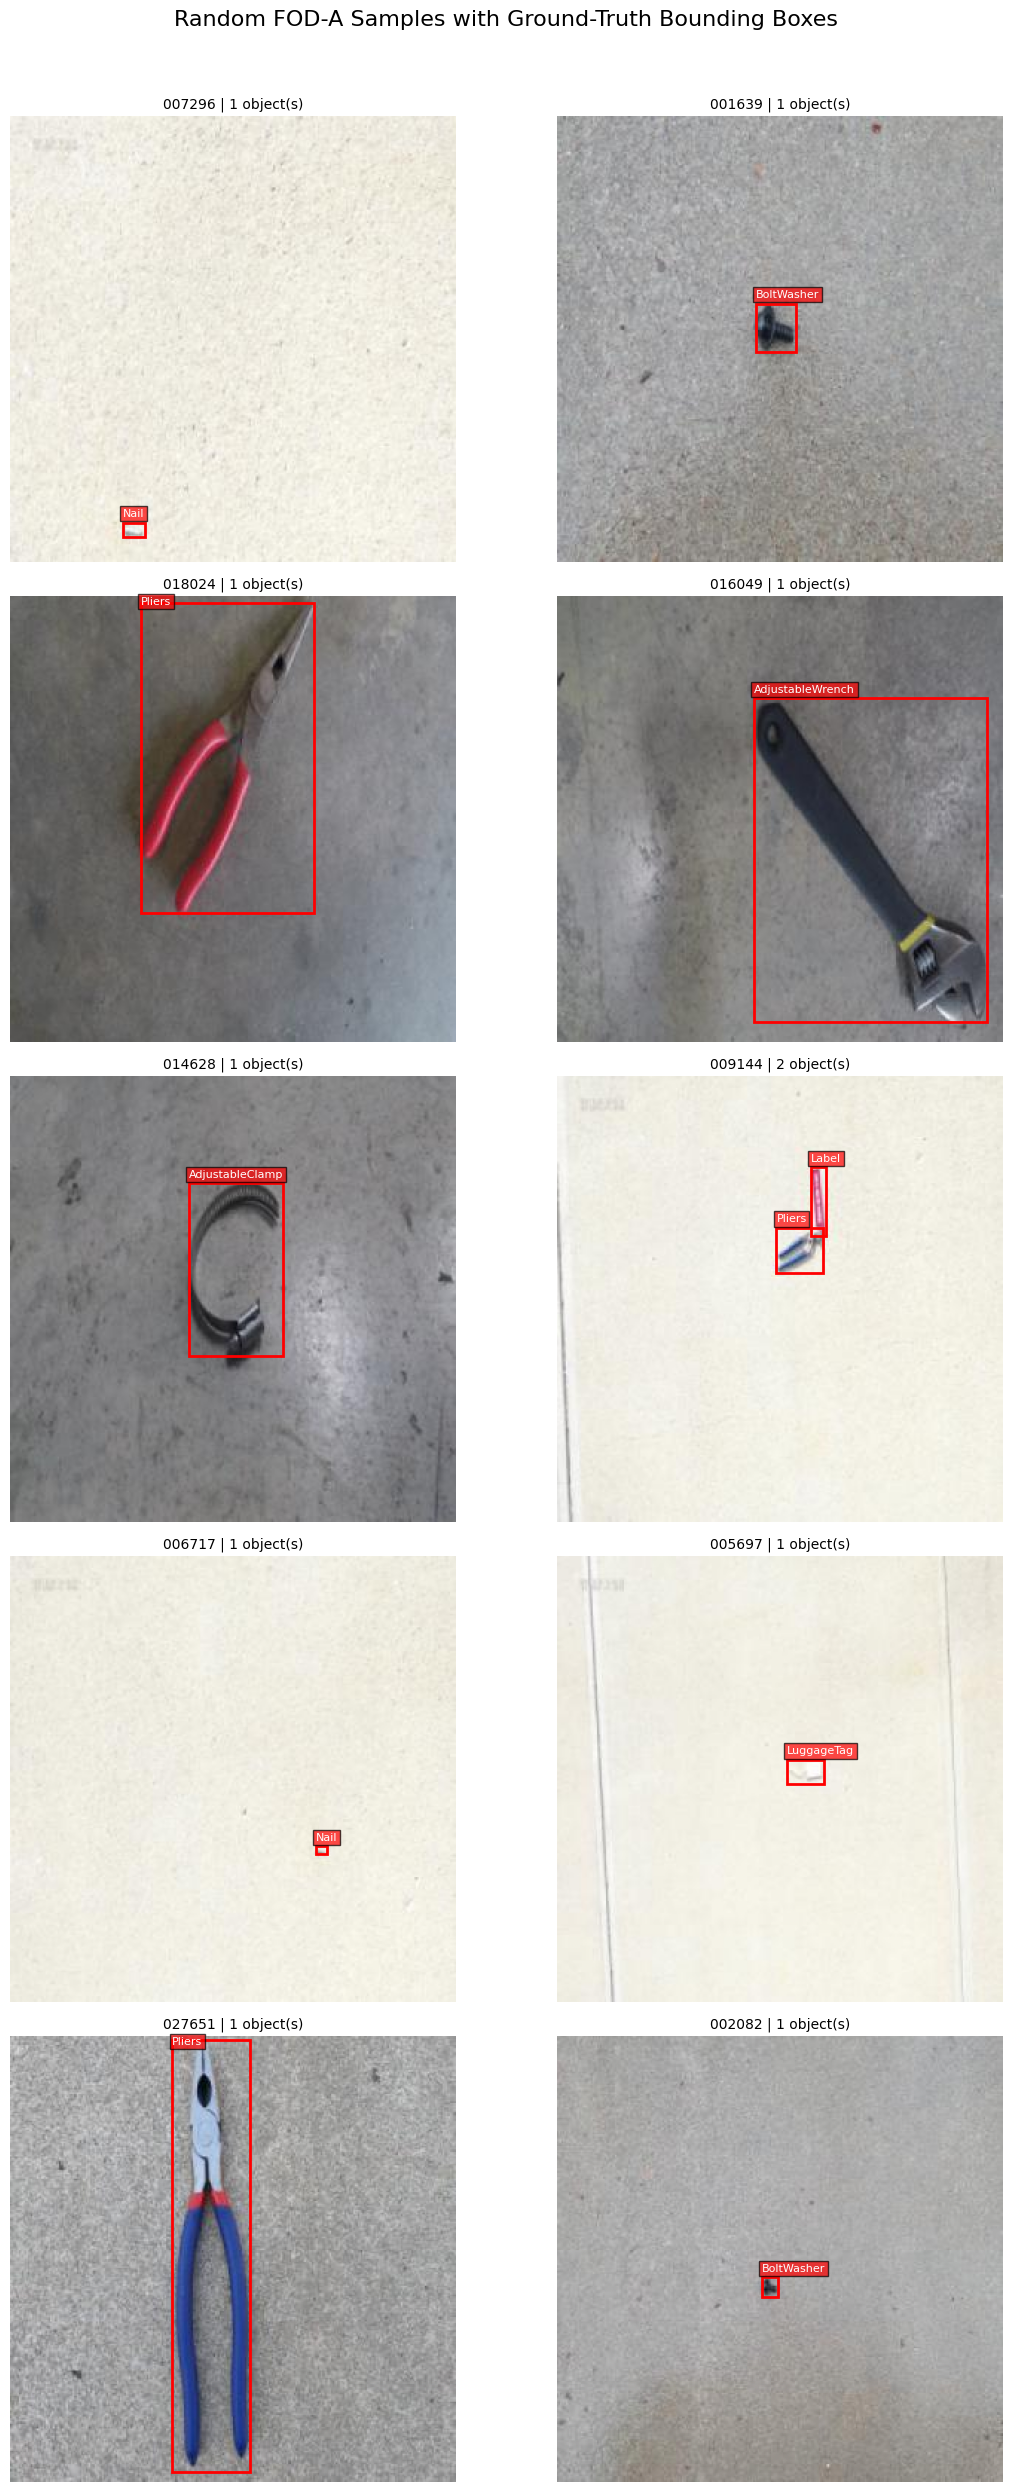

In [21]:
eda.visualize_random_samples(
    num_samples=10,
    seed=42
)